<a href="https://colab.research.google.com/github/ojasvagr123/ml-lab/blob/main/Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Imports**

In [ ]:
!pip -q install kaggle scikit-learn xgboost category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ojasvagrawal","key":"853468aa7c05e98564abc677558289c2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d pardeep19singh/icc-mens-world-cup-2023

Dataset URL: https://www.kaggle.com/datasets/pardeep19singh/icc-mens-world-cup-2023
License(s): CC0-1.0
100% 152k/152k [00:00<00:00, 78.8MB/s]



In [ ]:
!unzip -o icc-mens-world-cup-2023.zip -d icc_wc_2023

Archive:  icc-mens-world-cup-2023.zip
  inflating: icc_wc_2023/deliveries.csv  
  inflating: icc_wc_2023/matches.csv  
  inflating: icc_wc_2023/points_table.csv  


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

Dataset

In [ ]:
deliveries_path = "/content/icc_wc_2023/deliveries.csv"
matches_path = "/content/icc_wc_2023/matches.csv"
points_path = "/content/icc_wc_2023/points_table.csv"

df = pd.read_csv(deliveries_path)
matches_df = pd.read_csv(matches_path)
points_df = pd.read_csv(points_path)

print("Deliveries shape:", df.shape)
print("Matches shape:", matches_df.shape)
print("Points table shape:", points_df.shape)

Deliveries shape: (26119, 22)
Matches shape: (48, 18)
Points table shape: (10, 11)


In [ ]:
display(df.head())
display(matches_df.head())
display(points_df.head())

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.1,England,New Zealand,JM Bairstow,DJ Malan,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.2,England,New Zealand,JM Bairstow,DJ Malan,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.3,England,New Zealand,JM Bairstow,DJ Malan,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.4,England,New Zealand,DJ Malan,JM Bairstow,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.5,England,New Zealand,JM Bairstow,DJ Malan,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,season,team1,team2,date,match_number,venue,city,toss_winner,toss_decision,player_of_match,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,match_type
0,2023/24,England,New Zealand,2023/10/05,1,Narendra Modi Stadium,Ahmedabad,New Zealand,field,R Ravindra,HDPK Dharmasena,Nitin Menon,Sharfuddoula,J Srinath,New Zealand,NaN,9.0,Group
1,2023/24,Pakistan,Netherlands,2023/10/06,2,Rajiv Gandhi International Stadium,Hyderabad,Netherlands,field,Saud Shakeel,AT Holdstock,CM Brown,PR Reiffel,JJ Crowe,Pakistan,81.0,NaN,Group
2,2023/24,Afghanistan,Bangladesh,2023/10/07,3,Himachal Pradesh Cricket Association Stadium,Dharamsala,Bangladesh,field,Mehedi Hasan Miraz,JS Wilson,HDPK Dharmasena,M Erasmus,AJ Pycroft,Bangladesh,NaN,6.0,Group
3,2023/24,South Africa,Sri Lanka,2023/10/07,4,Arun Jaitley Stadium,Delhi,Sri Lanka,field,AK Markram,RK Illingworth,Sharfuddoula,AG Wharf,J Srinath,South Africa,102.0,NaN,Group
4,2023/24,Australia,India,2023/10/08,5,MA Chidambaram Stadium,Chennai,Australia,bat,KL Rahul,CB Gaffaney,RA Kettleborough,AT Holdstock,RB Richardson,India,NaN,6.0,Group


,Ranking,Team,Matches,Won,Lost,Tie,No Results,Points,Net Run Rate,For,Against
0,1,India,9,9,0,0,0,18,2.570,2523/396.2,1708/450.0
1,2,South Africa,9,7,2,0,0,14,1.261,2685/437.5,2158/443.0
2,3,Australia,9,7,2,0,0,14,0.841,2631/426.5,2349/441.2
3,4,New Zealand,9,5,4,0,0,10,0.743,2315/378.0,2279/423.3
4,5,Pakistan,9,4,5,0,0,8,-0.199,2328/406.2,2385/402.2


In [ ]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26119 entries, 0 to 26118
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                26119 non-null  int64  
 1   season                  26119 non-null  object 
 2   start_date              26119 non-null  object 
 3   venue                   26119 non-null  object 
 4   innings                 26119 non-null  int64  
 5   ball                    26119 non-null  float64
 6   batting_team            26119 non-null  object 
 7   bowling_team            26119 non-null  object 
 8   striker                 26119 non-null  object 
 9   non_striker             26119 non-null  object 
 10  bowler                  26119 non-null  object 
 11  runs_off_bat            26119 non-null  int64  
 12  extras                  26119 non-null  int64  
 13  wides                   665 non-null    float64
 14  noballs                 56 non-null   

In [ ]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26119 entries, 0 to 26118
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                26119 non-null  int64  
 1   season                  26119 non-null  object 
 2   start_date              26119 non-null  object 
 3   venue                   26119 non-null  object 
 4   innings                 26119 non-null  int64  
 5   ball                    26119 non-null  float64
 6   batting_team            26119 non-null  object 
 7   bowling_team            26119 non-null  object 
 8   striker                 26119 non-null  object 
 9   non_striker             26119 non-null  object 
 10  bowler                  26119 non-null  object 
 11  runs_off_bat            26119 non-null  int64  
 12  extras                  26119 non-null  int64  
 13  wides                   665 non-null    float64
 14  noballs                 56 non-null   

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
matches_df.columns = matches_df.columns.str.strip().str.lower().str.replace(" ", "_")
points_df.columns = points_df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())

['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']


In [ ]:
df["total_runs"] = df["runs_off_bat"] + df["extras"]

# wicket flag
wicket_col = None
for c in ["player_dismissed", "wicket_type", "wicket_kind"]:
    if c in df.columns:
        wicket_col = c
        break

if wicket_col is not None:
    df["wicket_fell"] = df[wicket_col].notna().astype(int)
else:
    df["wicket_fell"] = 0

df["over"] = df["ball"].astype(str).str.split(".").str[0].astype(int)
df["ball_in_over"] = df["ball"].astype(str).str.split(".").str[-1].astype(int)

df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,total_runs,wicket_fell,over,ball_in_over
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.1,England,New Zealand,JM Bairstow,DJ Malan,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.2,England,New Zealand,JM Bairstow,DJ Malan,...,NaN,NaN,NaN,NaN,NaN,NaN,6,0,0,2
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.3,England,New Zealand,JM Bairstow,DJ Malan,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,3
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.4,England,New Zealand,DJ Malan,JM Bairstow,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,4
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.5,England,New Zealand,JM Bairstow,DJ Malan,...,NaN,NaN,NaN,NaN,NaN,NaN,4,0,0,5


In [ ]:
for col in ["striker", "bowler", "batting_team", "bowling_team", "venue"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

df["innings"] = df["innings"].fillna(0)
df["match_id"] = df["match_id"].fillna(-1)

## **EDA**

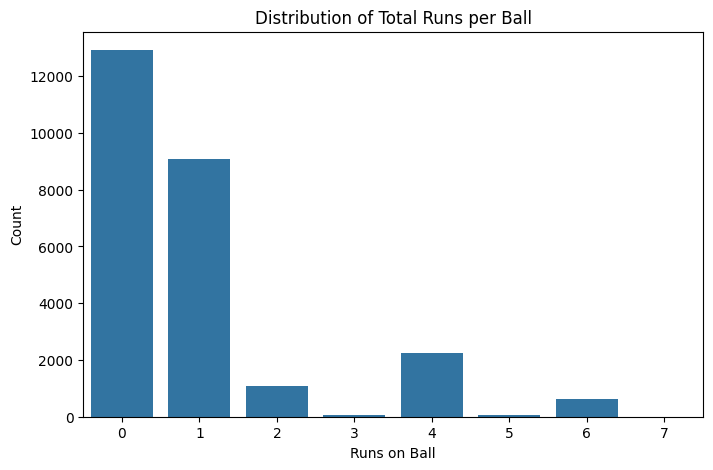

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="total_runs", data=df, order=sorted(df["total_runs"].unique()))
plt.title("Distribution of Total Runs per Ball")
plt.xlabel("Runs on Ball")
plt.ylabel("Count")
plt.show()

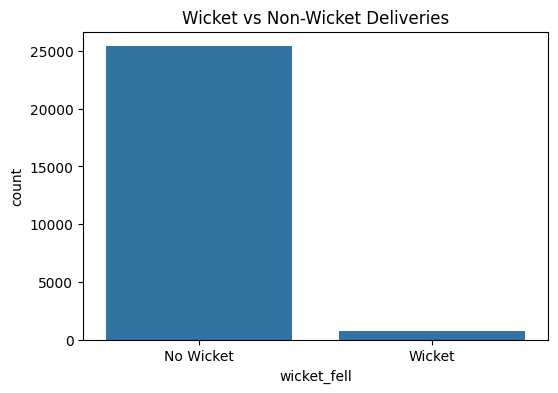

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="wicket_fell", data=df)
plt.title("Wicket vs Non-Wicket Deliveries")
plt.xticks([0,1], ["No Wicket", "Wicket"])
plt.show()

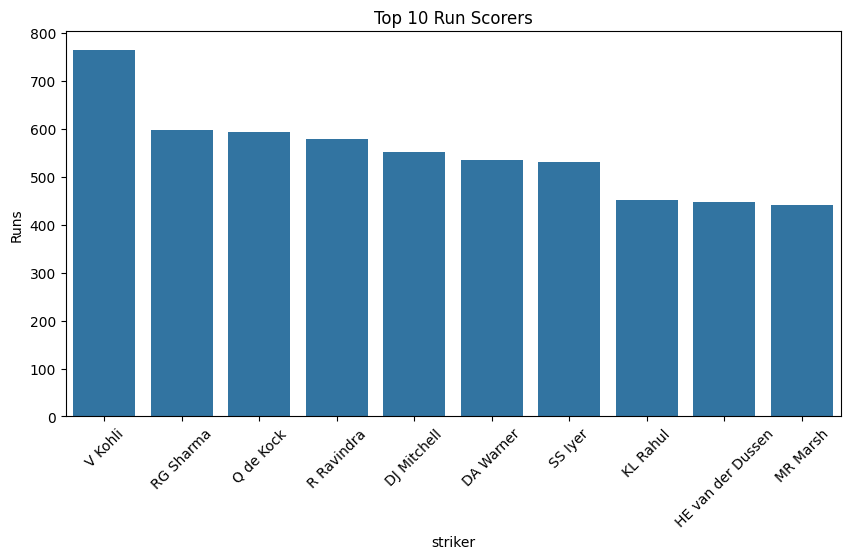

In [ ]:
top_batters = df.groupby("striker")["runs_off_bat"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_batters.index, y=top_batters.values)
plt.title("Top 10 Run Scorers")
plt.xticks(rotation=45)
plt.ylabel("Runs")
plt.show()

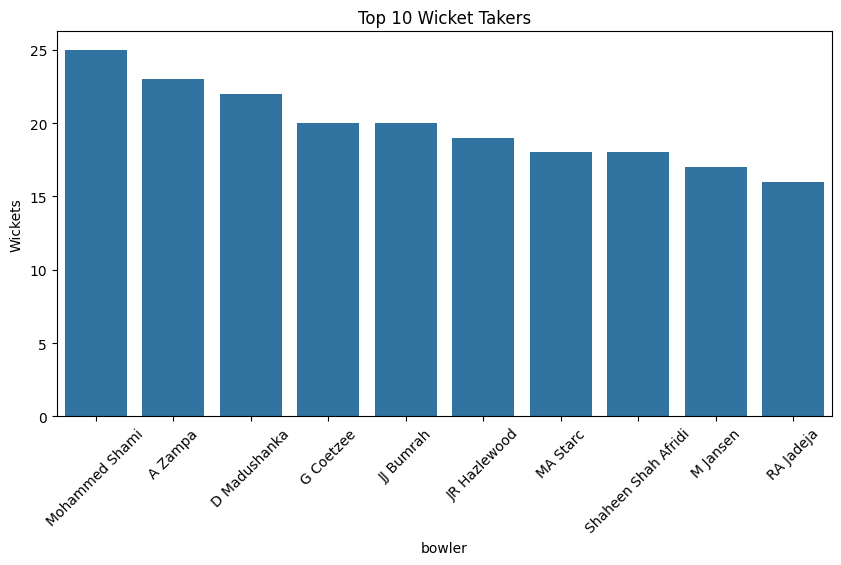

In [ ]:
top_bowlers = df.groupby("bowler")["wicket_fell"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_bowlers.index, y=top_bowlers.values)
plt.title("Top 10 Wicket Takers")
plt.xticks(rotation=45)
plt.ylabel("Wickets")
plt.show()

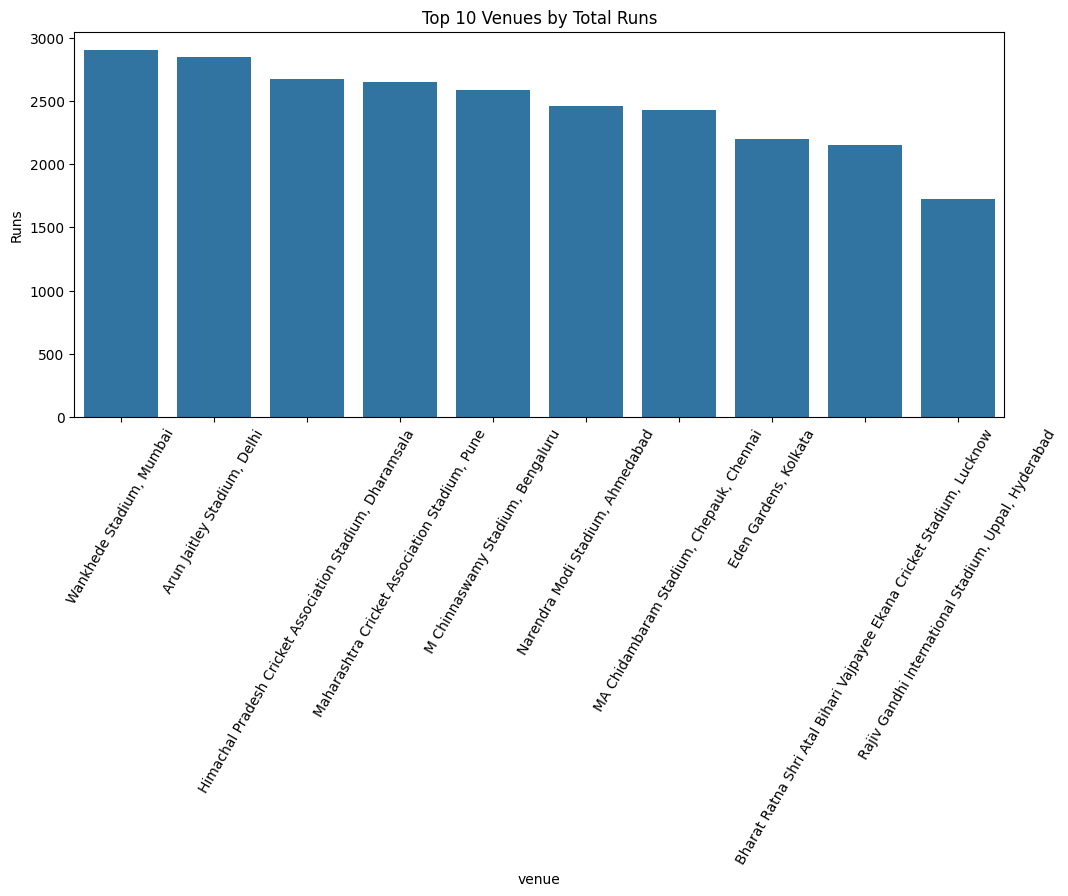

In [ ]:
if "venue" in df.columns:
    venue_runs = df.groupby("venue")["total_runs"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12,5))
    sns.barplot(x=venue_runs.index, y=venue_runs.values)
    plt.title("Top 10 Venues by Total Runs")
    plt.xticks(rotation=60)
    plt.ylabel("Runs")
    plt.show()

## **Feature Extraction**

In [ ]:
df = df.sort_values(["match_id", "innings", "ball"]).reset_index(drop=True)

df["cum_runs"] = df.groupby(["match_id", "innings"])["total_runs"].cumsum()
df["cum_wickets"] = df.groupby(["match_id", "innings"])["wicket_fell"].cumsum()

df["balls_bowled_in_innings"] = df.groupby(["match_id", "innings"]).cumcount() + 1
df["balls_left"] = 300 - df["balls_bowled_in_innings"]
df["wickets_left"] = 10 - df["cum_wickets"]

df["current_run_rate"] = (df["cum_runs"] / df["balls_bowled_in_innings"]) * 6

df["last_6_ball_runs"] = (
    df.groupby(["match_id", "innings"])["total_runs"]
      .rolling(window=6, min_periods=1)
      .sum()
      .reset_index(level=[0,1], drop=True)
)

df["last_6_ball_wickets"] = (
    df.groupby(["match_id", "innings"])["wicket_fell"]
      .rolling(window=6, min_periods=1)
      .sum()
      .reset_index(level=[0,1], drop=True)
)

df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,over,ball_in_over,cum_runs,cum_wickets,balls_bowled_in_innings,balls_left,wickets_left,current_run_rate,last_6_ball_runs,last_6_ball_wickets
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.1,England,New Zealand,JM Bairstow,DJ Malan,...,0,1,0,0,1,299,10,0.0,0.0,0.0
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.2,England,New Zealand,JM Bairstow,DJ Malan,...,0,2,6,0,2,298,10,18.0,6.0,0.0
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.3,England,New Zealand,JM Bairstow,DJ Malan,...,0,3,7,0,3,297,10,14.0,7.0,0.0
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.4,England,New Zealand,DJ Malan,JM Bairstow,...,0,4,8,0,4,296,10,12.0,8.0,0.0
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.5,England,New Zealand,JM Bairstow,DJ Malan,...,0,5,12,0,5,295,10,14.4,12.0,0.0


In [ ]:
df["target_wicket_next_ball"] = (
    df.groupby(["match_id", "innings"])["wicket_fell"].shift(-1)
)

df = df.dropna(subset=["target_wicket_next_ball"]).copy()
df["target_wicket_next_ball"] = df["target_wicket_next_ball"].astype(int)

df[[
    "match_id", "innings", "ball", "wicket_fell",
    "target_wicket_next_ball"
]].head(10)

,match_id,innings,ball,wicket_fell,target_wicket_next_ball
0,1,1,0.1,0,0
1,1,1,0.2,0,0
2,1,1,0.3,0,0
3,1,1,0.4,0,0
4,1,1,0.5,0,0
5,1,1,0.6,0,0
6,1,1,1.1,0,0
7,1,1,1.2,0,0
8,1,1,1.3,0,0
9,1,1,1.4,0,0


In [ ]:
feature_cols = [
    "innings", "over", "ball_in_over",
    "batting_team", "bowling_team",
    "striker", "bowler",
    "cum_runs", "cum_wickets",
    "balls_bowled_in_innings", "balls_left",
    "wickets_left", "current_run_rate",
    "last_6_ball_runs", "last_6_ball_wickets"
]

available_features = [col for col in feature_cols if col in df.columns]

X = df[available_features].copy()
y = df["target_wicket_next_ball"].copy()

print("Features used:", available_features)
print("Target distribution:\n", y.value_counts(normalize=True))

Features used: ['innings', 'over', 'ball_in_over', 'batting_team', 'bowling_team', 'striker', 'bowler', 'cum_runs', 'cum_wickets', 'balls_bowled_in_innings', 'balls_left', 'wickets_left', 'current_run_rate', 'last_6_ball_runs', 'last_6_ball_wickets']
Target distribution:
 target_wicket_next_ball
0    0.972102
1    0.027898
Name: proportion, dtype: float64


## **Preprocessing**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(20818, 15) (5205, 15)


In [ ]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['batting_team', 'bowling_team', 'striker', 'bowler']
Numeric: ['innings', 'over', 'ball_in_over', 'cum_runs', 'cum_wickets', 'balls_bowled_in_innings', 'balls_left', 'wickets_left', 'current_run_rate', 'last_6_ball_runs', 'last_6_ball_wickets']


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## **Model Training**

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_probs))
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.6476464937560038
Logistic Regression ROC-AUC: 0.5852037617554859
              precision    recall  f1-score   support

           0       0.98      0.65      0.78      5060
           1       0.04      0.47      0.07       145

    accuracy                           0.65      5205
   macro avg       0.51      0.56      0.43      5205
weighted avg       0.95      0.65      0.76      5205



In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9045148895292987
Random Forest ROC-AUC: 0.6023947117350416
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5060
           1       0.06      0.17      0.09       145

    accuracy                           0.90      5205
   macro avg       0.52      0.55      0.52      5205
weighted avg       0.95      0.90      0.93      5205



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

xgb_preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

xgb_model = Pipeline(steps=[
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 0.9719500480307397
XGBoost ROC-AUC: 0.5732492844486847
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      5060
           1       0.00      0.00      0.00       145

    accuracy                           0.97      5205
   macro avg       0.49      0.50      0.49      5205
weighted avg       0.95      0.97      0.96      5205



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
}).sort_values(by="ROC_AUC", ascending=False)

display(results)

,Model,Accuracy,ROC_AUC
1,Random Forest,0.904515,0.602395
0,Logistic Regression,0.647646,0.585204
2,XGBoost,0.971950,0.573249


In [ ]:
best_model_name = results.iloc[0]["Model"]
print("Best model is:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = log_model
    best_preds = log_preds
    best_probs = log_probs
elif best_model_name == "Random Forest":
    best_model = rf_model
    best_preds = rf_preds
    best_probs = rf_probs
else:
    best_model = xgb_model
    best_preds = xgb_preds
    best_probs = xgb_probs

Best model is: Random Forest


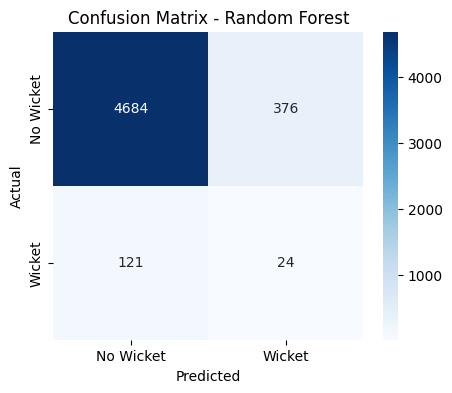

In [ ]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Wicket", "Wicket"],
            yticklabels=["No Wicket", "Wicket"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

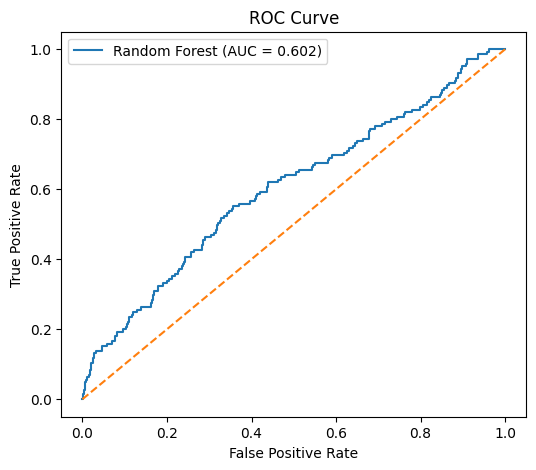

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, best_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, best_probs):.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## **Important Features**

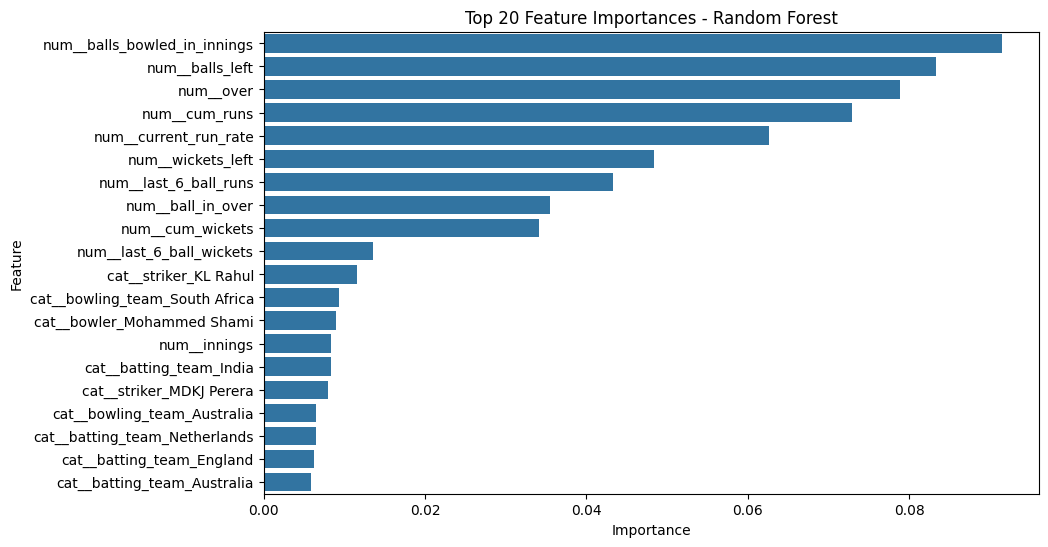

,Feature,Importance
5,num__balls_bowled_in_innings,0.091510
6,num__balls_left,0.083332
1,num__over,0.078911
3,num__cum_runs,0.072930
8,num__current_run_rate,0.062611
7,num__wickets_left,0.048320
9,num__last_6_ball_runs,0.043313
2,num__ball_in_over,0.035513
4,num__cum_wickets,0.034110
10,num__last_6_ball_wickets,0.013585


In [ ]:
if best_model_name in ["Random Forest", "XGBoost"]:
    ohe = best_model.named_steps["preprocessor"]

    try:
        feature_names = ohe.get_feature_names_out()
    except:
        feature_names = [f"feature_{i}" for i in range(len(best_model.named_steps["classifier"].feature_importances_))]

    importances = best_model.named_steps["classifier"].feature_importances_
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(data=fi, x="Importance", y="Feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.show()

    display(fi)
else:
    print("Feature importance plot is cleaner for tree-based models.")

## **Player Clustering**

In [ ]:
player_stats = df.groupby("striker").agg(
    total_runs=("runs_off_bat", "sum"),
    balls_faced=("runs_off_bat", "count"),
    fours=("runs_off_bat", lambda x: (x == 4).sum()),
    sixes=("runs_off_bat", lambda x: (x == 6).sum()),
    dismissals=("wicket_fell", "sum")
).reset_index()

player_stats["strike_rate"] = (player_stats["total_runs"] / player_stats["balls_faced"]) * 100
player_stats["boundary_pct"] = ((player_stats["fours"] + player_stats["sixes"]) / player_stats["balls_faced"]) * 100
player_stats["avg_runs_per_ball"] = player_stats["total_runs"] / player_stats["balls_faced"]

player_stats.head()

,striker,total_runs,balls_faced,fours,sixes,dismissals,strike_rate,boundary_pct,avg_runs_per_ball
0,A Dutt,70,90,1,5,5,77.777778,6.666667,0.777778
1,A Zampa,48,63,5,0,3,76.190476,7.936508,0.761905
2,AAP Atkinson,35,24,7,0,1,145.833333,29.166667,1.458333
3,AD Mathews,51,80,4,1,3,63.750000,6.250000,0.637500
4,AK Markram,400,376,44,8,9,106.382979,13.829787,1.063830


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = ["total_runs", "balls_faced", "strike_rate", "boundary_pct", "avg_runs_per_ball"]
cluster_data = player_stats[cluster_features].fillna(0)

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
player_stats["cluster"] = kmeans.fit_predict(cluster_scaled)

player_stats[["striker", "cluster"]].head()

,striker,cluster
0,A Dutt,1
1,A Zampa,1
2,AAP Atkinson,0
3,AD Mathews,1
4,AK Markram,2


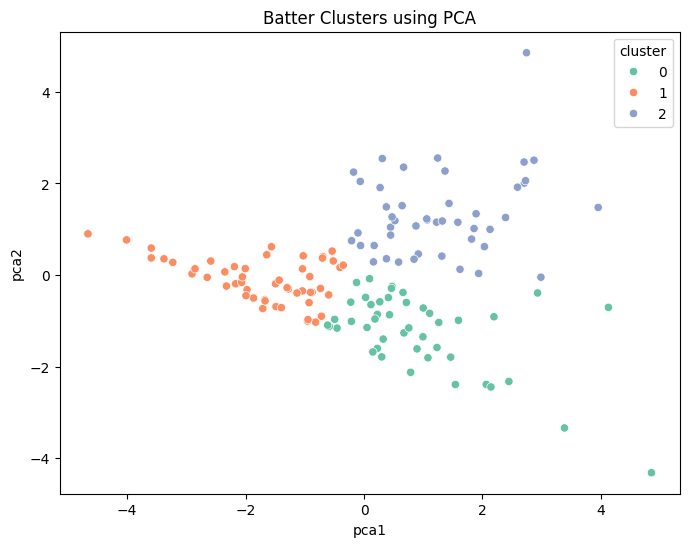

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(cluster_scaled)

player_stats["pca1"] = pca_data[:, 0]
player_stats["pca2"] = pca_data[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=player_stats, x="pca1", y="pca2", hue="cluster", palette="Set2")
plt.title("Batter Clusters using PCA")
plt.show()

In [ ]:
for c in sorted(player_stats["cluster"].unique()):
    print(f"\nCluster {c}")
    display(
        player_stats[player_stats["cluster"] == c]
        .sort_values("total_runs", ascending=False)
        [["striker", "total_runs", "strike_rate", "boundary_pct"]]
        .head(10)
    )


Cluster 0


,striker,total_runs,strike_rate,boundary_pct
36,GJ Maxwell,392,145.724907,22.676580
135,TM Head,329,126.053640,19.157088
32,Fakhar Zaman,220,120.879121,17.582418
38,HC Brook,169,111.920530,16.556291
7,AT Nidamanuru,164,95.906433,12.280702
48,Imam-ul-Haq,162,89.502762,12.707182
55,JP Inglis,159,92.441860,11.627907
68,M Jansen,156,106.849315,12.328767
136,TWM Latham,155,89.595376,8.670520
76,MDKJ Perera,149,97.385621,17.647059



Cluster 1


,striker,total_runs,strike_rate,boundary_pct
140,Towhid Hridoy,164,76.995305,5.633803
131,T Bavuma,145,72.500000,10.500000
28,DM de Silva,140,75.268817,9.139785
66,LV van Beek,140,73.684211,6.315789
13,BFW de Leede,139,68.472906,8.374384
80,MP O'Dowd,138,65.714286,11.428571
103,PJ Cummins,118,61.458333,8.333333
71,M Theekshana,100,52.910053,6.349206
143,Vikramjit Singh,98,64.052288,8.496732
79,MM Ali,95,72.519084,6.870229



Cluster 2


,striker,total_runs,strike_rate,boundary_pct
142,V Kohli,754,87.369641,8.690614
110,RG Sharma,597,123.092784,20.000000
105,Q de Kock,594,104.393673,13.708260
107,R Ravindra,577,103.405018,12.903226
26,DJ Mitchell,546,107.058824,13.529412
24,DA Warner,535,104.901961,14.509804
122,SS Iyer,526,108.677686,12.396694
39,HE van der Dussen,448,82.962963,8.703704
60,KL Rahul,442,88.047809,8.964143
82,MR Marsh,441,105.250597,15.274463


In [ ]:
pred_output = X_test.copy()
pred_output["actual"] = y_test.values
pred_output["predicted"] = best_preds
pred_output["wicket_probability"] = best_probs

pred_output.to_csv("wicket_prediction_results.csv", index=False)
player_stats.to_csv("batter_clusters.csv", index=False)

print("Saved files:")
print("- wicket_prediction_results.csv")
print("- batter_clusters.csv")

Saved files:
- wicket_prediction_results.csv
- batter_clusters.csv


In [ ]:
from google.colab import files

files.download("wicket_prediction_results.csv")
files.download("batter_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **WIN PREDICTION**

In [ ]:
print(matches_df.columns.tolist())
display(matches_df.head())

['season', 'team1', 'team2', 'date', 'match_number', 'venue', 'city', 'toss_winner', 'toss_decision', 'player_of_match', 'umpire1', 'umpire2', 'reserve_umpire', 'match_referee', 'winner', 'winner_runs', 'winner_wickets', 'match_type']


,season,team1,team2,date,match_number,venue,city,toss_winner,toss_decision,player_of_match,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,match_type
0,2023/24,England,New Zealand,2023/10/05,1,Narendra Modi Stadium,Ahmedabad,New Zealand,field,R Ravindra,HDPK Dharmasena,Nitin Menon,Sharfuddoula,J Srinath,New Zealand,NaN,9.0,Group
1,2023/24,Pakistan,Netherlands,2023/10/06,2,Rajiv Gandhi International Stadium,Hyderabad,Netherlands,field,Saud Shakeel,AT Holdstock,CM Brown,PR Reiffel,JJ Crowe,Pakistan,81.0,NaN,Group
2,2023/24,Afghanistan,Bangladesh,2023/10/07,3,Himachal Pradesh Cricket Association Stadium,Dharamsala,Bangladesh,field,Mehedi Hasan Miraz,JS Wilson,HDPK Dharmasena,M Erasmus,AJ Pycroft,Bangladesh,NaN,6.0,Group
3,2023/24,South Africa,Sri Lanka,2023/10/07,4,Arun Jaitley Stadium,Delhi,Sri Lanka,field,AK Markram,RK Illingworth,Sharfuddoula,AG Wharf,J Srinath,South Africa,102.0,NaN,Group
4,2023/24,Australia,India,2023/10/08,5,MA Chidambaram Stadium,Chennai,Australia,bat,KL Rahul,CB Gaffaney,RA Kettleborough,AT Holdstock,RB Richardson,India,NaN,6.0,Group


In [ ]:
matches_df.columns = matches_df.columns.str.strip().str.lower().str.replace(" ", "_")
display(matches_df.head())

,season,team1,team2,date,match_number,venue,city,toss_winner,toss_decision,player_of_match,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,match_type
0,2023/24,England,New Zealand,2023/10/05,1,Narendra Modi Stadium,Ahmedabad,New Zealand,field,R Ravindra,HDPK Dharmasena,Nitin Menon,Sharfuddoula,J Srinath,New Zealand,NaN,9.0,Group
1,2023/24,Pakistan,Netherlands,2023/10/06,2,Rajiv Gandhi International Stadium,Hyderabad,Netherlands,field,Saud Shakeel,AT Holdstock,CM Brown,PR Reiffel,JJ Crowe,Pakistan,81.0,NaN,Group
2,2023/24,Afghanistan,Bangladesh,2023/10/07,3,Himachal Pradesh Cricket Association Stadium,Dharamsala,Bangladesh,field,Mehedi Hasan Miraz,JS Wilson,HDPK Dharmasena,M Erasmus,AJ Pycroft,Bangladesh,NaN,6.0,Group
3,2023/24,South Africa,Sri Lanka,2023/10/07,4,Arun Jaitley Stadium,Delhi,Sri Lanka,field,AK Markram,RK Illingworth,Sharfuddoula,AG Wharf,J Srinath,South Africa,102.0,NaN,Group
4,2023/24,Australia,India,2023/10/08,5,MA Chidambaram Stadium,Chennai,Australia,bat,KL Rahul,CB Gaffaney,RA Kettleborough,AT Holdstock,RB Richardson,India,NaN,6.0,Group


In [ ]:
print("Matches columns:")
for col in matches_df.columns:
    print(col)

Matches columns:
season
team1
team2
date
match_number
venue
city
toss_winner
toss_decision
player_of_match
umpire1
umpire2
reserve_umpire
match_referee
winner
winner_runs
winner_wickets
match_type


In [ ]:
winner_col = None
team1_col = None
team2_col = None

for c in ["winner", "winning_team"]:
    if c in matches_df.columns:
        winner_col = c
        break

for c in ["team1", "first_team"]:
    if c in matches_df.columns:
        team1_col = c
        break

for c in ["team2", "second_team"]:
    if c in matches_df.columns:
        team2_col = c
        break

print("winner_col:", winner_col)
print("team1_col:", team1_col)
print("team2_col:", team2_col)

winner_col: winner
team1_col: team1
team2_col: team2


In [ ]:
winner_col = None
team1_col = None
team2_col = None

for c in ["winner", "winning_team"]:
    if c in matches_df.columns:
        winner_col = c
        break

for c in ["team1", "first_team"]:
    if c in matches_df.columns:
        team1_col = c
        break

for c in ["team2", "second_team"]:
    if c in matches_df.columns:
        team2_col = c
        break

print("winner_col:", winner_col)
print("team1_col:", team1_col)
print("team2_col:", team2_col)

winner_col: winner
team1_col: team1
team2_col: team2


In [ ]:
winner_col = None
team1_col = None
team2_col = None

for c in ["winner", "winning_team"]:
    if c in matches_df.columns:
        winner_col = c
        break

for c in ["team1", "first_team"]:
    if c in matches_df.columns:
        team1_col = c
        break

for c in ["team2", "second_team"]:
    if c in matches_df.columns:
        team2_col = c
        break

print("winner_col:", winner_col)
print("team1_col:", team1_col)
print("team2_col:", team2_col)

winner_col: winner
team1_col: team1
team2_col: team2


In [ ]:
innings1_total = (
    df[df["innings"] == 1]
    .groupby("match_id")["total_runs"]
    .sum()
    .reset_index()
    .rename(columns={"total_runs": "innings1_total"})
)

innings1_total["target"] = innings1_total["innings1_total"] + 1
display(innings1_total.head())

,match_id,innings1_total,target
0,1,281,282
1,2,286,287
2,3,156,157
3,4,427,428
4,5,199,200


In [ ]:
wp_df = df.merge(innings1_total[["match_id", "innings1_total", "target"]], on="match_id", how="left")
display(wp_df.head())

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,cum_wickets,balls_bowled_in_innings,balls_left,wickets_left,current_run_rate,last_6_ball_runs,last_6_ball_wickets,target_wicket_next_ball,innings1_total,target
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.1,England,New Zealand,JM Bairstow,DJ Malan,...,0,1,299,10,0.0,0.0,0.0,0,281,282
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.2,England,New Zealand,JM Bairstow,DJ Malan,...,0,2,298,10,18.0,6.0,0.0,0,281,282
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.3,England,New Zealand,JM Bairstow,DJ Malan,...,0,3,297,10,14.0,7.0,0.0,0,281,282
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.4,England,New Zealand,DJ Malan,JM Bairstow,...,0,4,296,10,12.0,8.0,0.0,0,281,282
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",1,0.5,England,New Zealand,JM Bairstow,DJ Malan,...,0,5,295,10,14.4,12.0,0.0,0,281,282


In [ ]:
wp_df = wp_df[wp_df["innings"] == 2].copy()
print("Second innings rows:", wp_df.shape)
display(wp_df.head())

Second innings rows: (11676, 37)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,cum_wickets,balls_bowled_in_innings,balls_left,wickets_left,current_run_rate,last_6_ball_runs,last_6_ball_wickets,target_wicket_next_ball,innings1_total,target
303,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.1,New Zealand,England,DP Conway,WA Young,...,0,1,299,10,24.0,4.0,0.0,0,281,282
304,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.2,New Zealand,England,DP Conway,WA Young,...,0,2,298,10,12.0,4.0,0.0,0,281,282
305,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.3,New Zealand,England,DP Conway,WA Young,...,0,3,297,10,8.0,4.0,0.0,0,281,282
306,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.4,New Zealand,England,DP Conway,WA Young,...,0,4,296,10,9.0,6.0,0.0,0,281,282
307,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.5,New Zealand,England,DP Conway,WA Young,...,0,5,295,10,12.0,10.0,0.0,0,281,282


In [ ]:
if winner_col is None:
    raise ValueError("Winner column not found in matches_df. Please check matches_df columns manually.")

# Rename 'match_number' to 'match_id' in matches_df
matches_df = matches_df.rename(columns={"match_number": "match_id"})

match_result_df = matches_df[["match_id", winner_col]].copy()
match_result_df = match_result_df.rename(columns={winner_col: "match_winner"})

wp_df = wp_df.merge(match_result_df, on="match_id", how="left")
display(wp_df[["match_id", "batting_team", "bowling_team", "match_winner"]].head())

,match_id,batting_team,bowling_team,match_winner
0,1,New Zealand,England,New Zealand
1,1,New Zealand,England,New Zealand
2,1,New Zealand,England,New Zealand
3,1,New Zealand,England,New Zealand
4,1,New Zealand,England,New Zealand


In [ ]:
wp_df["chasing_team"] = wp_df["batting_team"]
wp_df["final_result"] = (wp_df["chasing_team"] == wp_df["match_winner"]).astype(int)

wp_df[["match_id", "chasing_team", "match_winner", "final_result"]].head()

,match_id,chasing_team,match_winner,final_result
0,1,New Zealand,New Zealand,1
1,1,New Zealand,New Zealand,1
2,1,New Zealand,New Zealand,1
3,1,New Zealand,New Zealand,1
4,1,New Zealand,New Zealand,1


In [ ]:
wp_df = wp_df.sort_values(["match_id", "ball"]).reset_index(drop=True)

wp_df["cum_runs_2nd"] = wp_df.groupby("match_id")["total_runs"].cumsum()
wp_df["cum_wickets_2nd"] = wp_df.groupby("match_id")["wicket_fell"].cumsum()

wp_df["balls_bowled_2nd"] = wp_df.groupby("match_id").cumcount() + 1
wp_df["balls_left"] = 300 - wp_df["balls_bowled_2nd"]
wp_df["wickets_left"] = 10 - wp_df["cum_wickets_2nd"]

wp_df["runs_required"] = wp_df["target"] - wp_df["cum_runs_2nd"]
wp_df["runs_required"] = wp_df["runs_required"].clip(lower=0)

wp_df["current_run_rate"] = (wp_df["cum_runs_2nd"] / wp_df["balls_bowled_2nd"]) * 6

wp_df["required_run_rate"] = np.where(
    wp_df["balls_left"] > 0,
    (wp_df["runs_required"] / wp_df["balls_left"]) * 6,
    0
)

wp_df["rrr_minus_crr"] = wp_df["required_run_rate"] - wp_df["current_run_rate"]

wp_df["last_6_runs"] = (
    wp_df.groupby("match_id")["total_runs"]
    .rolling(window=6, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

wp_df["last_6_wickets"] = (
    wp_df.groupby("match_id")["wicket_fell"]
    .rolling(window=6, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

display(wp_df.head())

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,chasing_team,final_result,cum_runs_2nd,cum_wickets_2nd,balls_bowled_2nd,runs_required,required_run_rate,rrr_minus_crr,last_6_runs,last_6_wickets
0,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.1,New Zealand,England,DP Conway,WA Young,...,New Zealand,1,4,0,1,278,5.578595,-18.421405,4.0,0.0
1,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.2,New Zealand,England,DP Conway,WA Young,...,New Zealand,1,4,0,2,278,5.597315,-6.402685,4.0,0.0
2,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.3,New Zealand,England,DP Conway,WA Young,...,New Zealand,1,4,0,3,278,5.616162,-2.383838,4.0,0.0
3,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.4,New Zealand,England,DP Conway,WA Young,...,New Zealand,1,6,0,4,276,5.594595,-3.405405,6.0,0.0
4,1,2023/24,2023-10-05,"Narendra Modi Stadium, Ahmedabad",2,0.5,New Zealand,England,DP Conway,WA Young,...,New Zealand,1,10,0,5,272,5.532203,-6.467797,10.0,0.0


In [ ]:
wp_df = wp_df[wp_df["balls_left"] >= 0].copy()
wp_df = wp_df[wp_df["wickets_left"] >= 0].copy()
wp_df = wp_df.dropna(subset=["final_result"])
print(wp_df.shape)

(11655, 48)


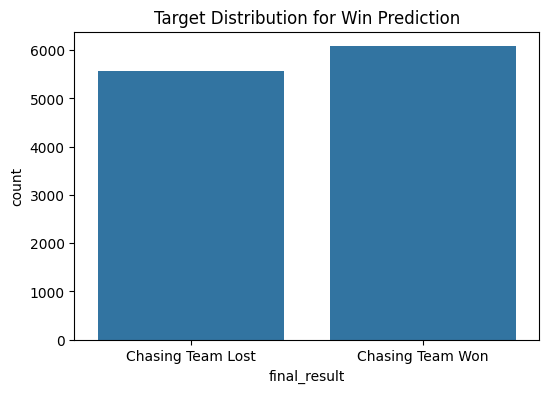

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="final_result", data=wp_df)
plt.xticks([0,1], ["Chasing Team Lost", "Chasing Team Won"])
plt.title("Target Distribution for Win Prediction")
plt.show()

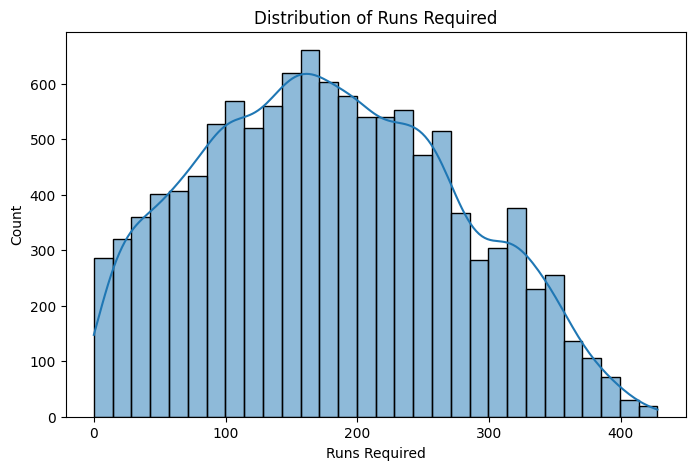

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(wp_df["runs_required"], bins=30, kde=True)
plt.title("Distribution of Runs Required")
plt.xlabel("Runs Required")
plt.show()

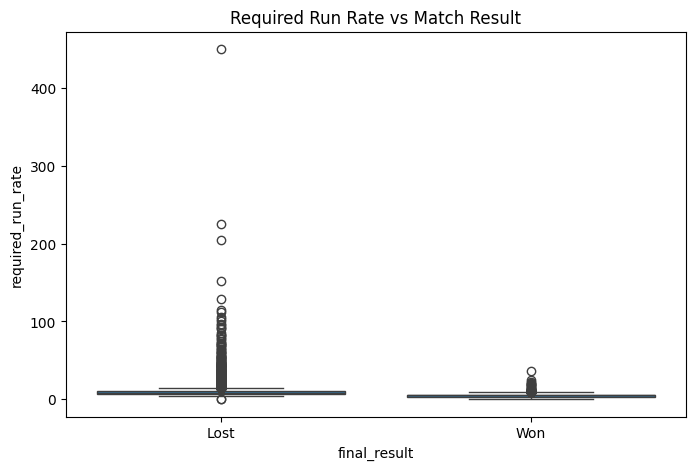

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="final_result", y="required_run_rate", data=wp_df)
plt.xticks([0,1], ["Lost", "Won"])
plt.title("Required Run Rate vs Match Result")
plt.show()

In [ ]:
wp_features = [
    "over",
    "ball_in_over",
    "batting_team",
    "bowling_team",
    "cum_runs_2nd",
    "cum_wickets_2nd",
    "balls_bowled_2nd",
    "balls_left",
    "wickets_left",
    "target",
    "runs_required",
    "current_run_rate",
    "required_run_rate",
    "rrr_minus_crr",
    "last_6_runs",
    "last_6_wickets"
]

wp_features = [col for col in wp_features if col in wp_df.columns]

X_wp = wp_df[wp_features].copy()
y_wp = wp_df["final_result"].copy()

print("Features used:", wp_features)
print(y_wp.value_counts())

Features used: ['over', 'ball_in_over', 'batting_team', 'bowling_team', 'cum_runs_2nd', 'cum_wickets_2nd', 'balls_bowled_2nd', 'balls_left', 'wickets_left', 'target', 'runs_required', 'current_run_rate', 'required_run_rate', 'rrr_minus_crr', 'last_6_runs', 'last_6_wickets']
final_result
1    6080
0    5575
Name: count, dtype: int64


In [ ]:
X_wp_train, X_wp_test, y_wp_train, y_wp_test = train_test_split(
    X_wp, y_wp,
    test_size=0.2,
    random_state=42,
    stratify=y_wp
)

print(X_wp_train.shape, X_wp_test.shape)

(9324, 16) (2331, 16)


In [ ]:
wp_cat_cols = X_wp_train.select_dtypes(include=["object"]).columns.tolist()
wp_num_cols = X_wp_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", wp_cat_cols)
print("Numeric:", wp_num_cols)

wp_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

wp_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

wp_preprocessor = ColumnTransformer(transformers=[
    ("num", wp_numeric_transformer, wp_num_cols),
    ("cat", wp_categorical_transformer, wp_cat_cols)
])

Categorical: ['batting_team', 'bowling_team']
Numeric: ['over', 'ball_in_over', 'cum_runs_2nd', 'cum_wickets_2nd', 'balls_bowled_2nd', 'balls_left', 'wickets_left', 'target', 'runs_required', 'current_run_rate', 'required_run_rate', 'rrr_minus_crr', 'last_6_runs', 'last_6_wickets']


In [ ]:
wp_log_model = Pipeline(steps=[
    ("preprocessor", wp_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

wp_log_model.fit(X_wp_train, y_wp_train)
wp_log_preds = wp_log_model.predict(X_wp_test)
wp_log_probs = wp_log_model.predict_proba(X_wp_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_wp_test, wp_log_preds))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_wp_test, wp_log_probs))
print(classification_report(y_wp_test, wp_log_preds))

Logistic Regression Accuracy: 0.9957099957099957
Logistic Regression ROC-AUC: 0.9995781213122492
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1115
           1       1.00      0.99      1.00      1216

    accuracy                           1.00      2331
   macro avg       1.00      1.00      1.00      2331
weighted avg       1.00      1.00      1.00      2331



In [ ]:
wp_rf_model = Pipeline(steps=[
    ("preprocessor", wp_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        min_samples_split=5,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

wp_rf_model.fit(X_wp_train, y_wp_train)
wp_rf_preds = wp_rf_model.predict(X_wp_test)
wp_rf_probs = wp_rf_model.predict_proba(X_wp_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_wp_test, wp_rf_preds))
print("Random Forest ROC-AUC:", roc_auc_score(y_wp_test, wp_rf_probs))
print(classification_report(y_wp_test, wp_rf_preds))

Random Forest Accuracy: 1.0
Random Forest ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1115
           1       1.00      1.00      1.00      1216

    accuracy                           1.00      2331
   macro avg       1.00      1.00      1.00      2331
weighted avg       1.00      1.00      1.00      2331



In [ ]:
wp_xgb_preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), wp_num_cols),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), wp_cat_cols)
])

wp_xgb_model = Pipeline(steps=[
    ("preprocessor", wp_xgb_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ))
])

wp_xgb_model.fit(X_wp_train, y_wp_train)
wp_xgb_preds = wp_xgb_model.predict(X_wp_test)
wp_xgb_probs = wp_xgb_model.predict_proba(X_wp_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_wp_test, wp_xgb_preds))
print("XGBoost ROC-AUC:", roc_auc_score(y_wp_test, wp_xgb_probs))
print(classification_report(y_wp_test, wp_xgb_preds))

XGBoost Accuracy: 1.0
XGBoost ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1115
           1       1.00      1.00      1.00      1216

    accuracy                           1.00      2331
   macro avg       1.00      1.00      1.00      2331
weighted avg       1.00      1.00      1.00      2331



In [ ]:
wp_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_wp_test, wp_log_preds),
        accuracy_score(y_wp_test, wp_rf_preds),
        accuracy_score(y_wp_test, wp_xgb_preds)
    ],
    "ROC_AUC": [
        roc_auc_score(y_wp_test, wp_log_probs),
        roc_auc_score(y_wp_test, wp_rf_probs),
        roc_auc_score(y_wp_test, wp_xgb_probs)
    ]
}).sort_values(by="ROC_AUC", ascending=False)

wp_best_model_name = wp_results.iloc[0]["Model"]
print("Best Win Prediction Model:", wp_best_model_name)

if wp_best_model_name == "Logistic Regression":
    wp_best_model = wp_log_model
    wp_best_preds = wp_log_preds
    wp_best_probs = wp_log_probs
elif wp_best_model_name == "Random Forest":
    wp_best_model = wp_rf_model
    wp_best_preds = wp_rf_preds
    wp_best_probs = wp_rf_probs
else:
    wp_best_model = wp_xgb_model
    wp_best_preds = wp_xgb_preds
    wp_best_probs = wp_xgb_probs

Best Win Prediction Model: Random Forest


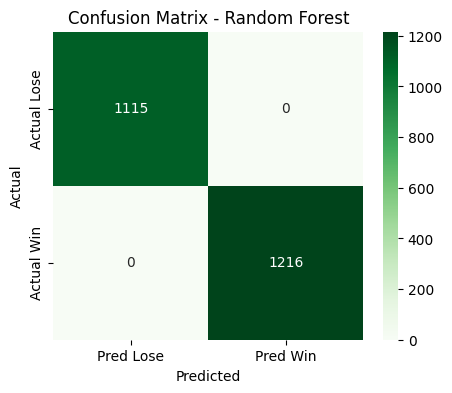

In [ ]:
wp_cm = confusion_matrix(y_wp_test, wp_best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    wp_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred Lose", "Pred Win"],
    yticklabels=["Actual Lose", "Actual Win"]
)
plt.title(f"Confusion Matrix - {wp_best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

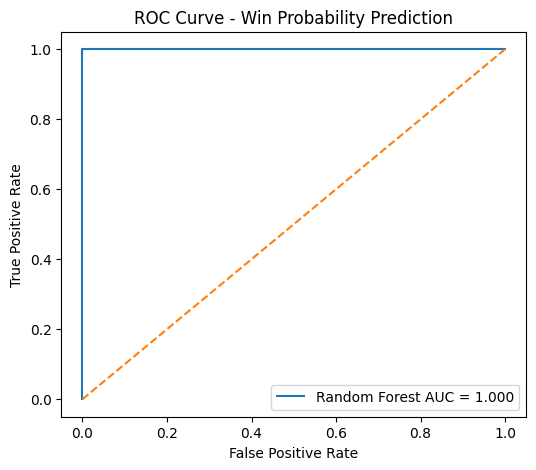

In [ ]:
wp_fpr, wp_tpr, _ = roc_curve(y_wp_test, wp_best_probs)

plt.figure(figsize=(6,5))
plt.plot(wp_fpr, wp_tpr, label=f"{wp_best_model_name} AUC = {roc_auc_score(y_wp_test, wp_best_probs):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Win Probability Prediction")
plt.legend()
plt.show()

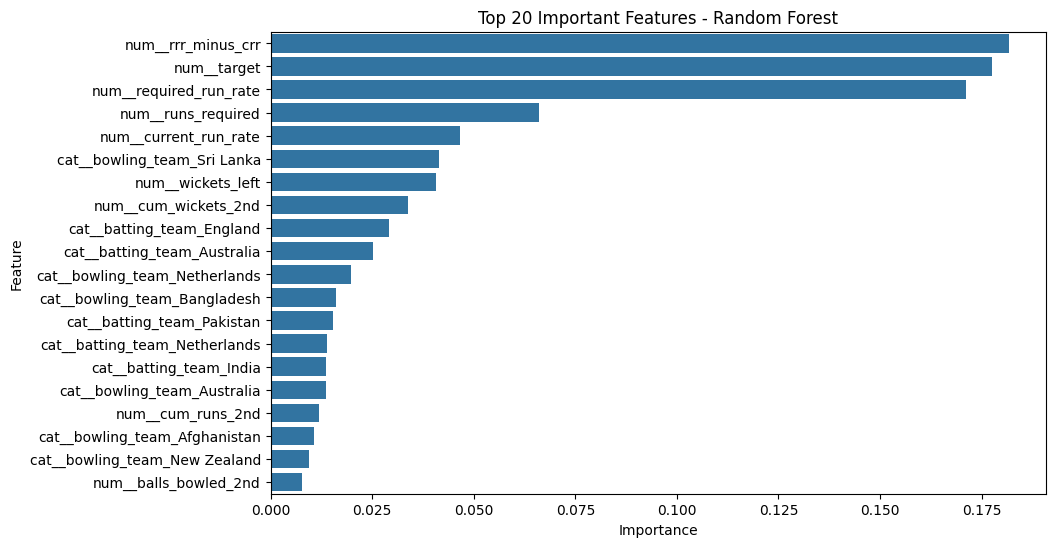

,Feature,Importance
11,num__rrr_minus_crr,0.181673
7,num__target,0.177565
10,num__required_run_rate,0.171053
8,num__runs_required,0.066136
9,num__current_run_rate,0.046490
33,cat__bowling_team_Sri Lanka,0.041485
6,num__wickets_left,0.040612
3,num__cum_wickets_2nd,0.033860
17,cat__batting_team_England,0.029100
15,cat__batting_team_Australia,0.025154


In [ ]:
if wp_best_model_name in ["Random Forest", "XGBoost"]:
    try:
        wp_feature_names = wp_best_model.named_steps["preprocessor"].get_feature_names_out()
    except:
        wp_feature_names = [f"feature_{i}" for i in range(len(wp_best_model.named_steps["classifier"].feature_importances_))]

    wp_importances = wp_best_model.named_steps["classifier"].feature_importances_

    wp_fi = pd.DataFrame({
        "Feature": wp_feature_names,
        "Importance": wp_importances
    }).sort_values(by="Importance", ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(data=wp_fi, x="Importance", y="Feature")
    plt.title(f"Top 20 Important Features - {wp_best_model_name}")
    plt.show()

    display(wp_fi)
else:
    print("Feature importance is more meaningful for tree-based models.")

In [ ]:
sample_wp = X_wp_test.iloc[:10].copy()
sample_wp["actual_result"] = y_wp_test.iloc[:10].values
sample_wp["predicted_win_probability"] = wp_best_model.predict_proba(X_wp_test.iloc[:10])[:, 1]
sample_wp["predicted_class"] = wp_best_model.predict(X_wp_test.iloc[:10])

display(sample_wp)

,over,ball_in_over,batting_team,bowling_team,cum_runs_2nd,cum_wickets_2nd,balls_bowled_2nd,balls_left,wickets_left,target,runs_required,current_run_rate,required_run_rate,rrr_minus_crr,last_6_runs,last_6_wickets,actual_result,predicted_win_probability,predicted_class
955,43,1,Sri Lanka,South Africa,321,8,270,30,2,428,107,7.133333,21.400000,14.266667,3.0,0.0,0,0.000000,0
10818,0,5,New Zealand,India,8,0,5,295,10,394,386,9.600000,7.850847,-1.749153,8.0,0.0,0,0.008740,0
4137,31,6,India,Bangladesh,191,3,194,106,7,251,60,5.907216,3.396226,-2.510990,3.0,0.0,1,1.000000,1
5200,47,3,India,New Zealand,269,5,289,11,5,274,5,5.584775,2.727273,-2.857502,4.0,0.0,1,1.000000,1
7113,26,3,England,India,92,6,163,137,4,230,138,3.386503,6.043796,2.657293,3.0,0.0,0,0.000000,0
9464,21,6,Netherlands,England,89,3,135,165,7,338,249,3.955556,9.054545,5.098990,7.0,0.0,0,0.000000,0
28,4,5,New Zealand,England,23,1,29,271,9,282,259,4.758621,5.734317,0.975697,4.0,0.0,1,0.786988,1
8860,11,4,Bangladesh,Sri Lanka,67,2,73,227,8,280,213,5.506849,5.629956,0.123107,8.0,0.0,1,0.996747,1
7367,32,6,Afghanistan,Sri Lanka,153,3,203,97,7,241,88,4.522167,5.443299,0.921131,4.0,0.0,1,1.000000,1
518,7,1,Bangladesh,Afghanistan,27,2,45,255,8,157,130,3.600000,3.058824,-0.541176,3.0,1.0,1,0.986915,1


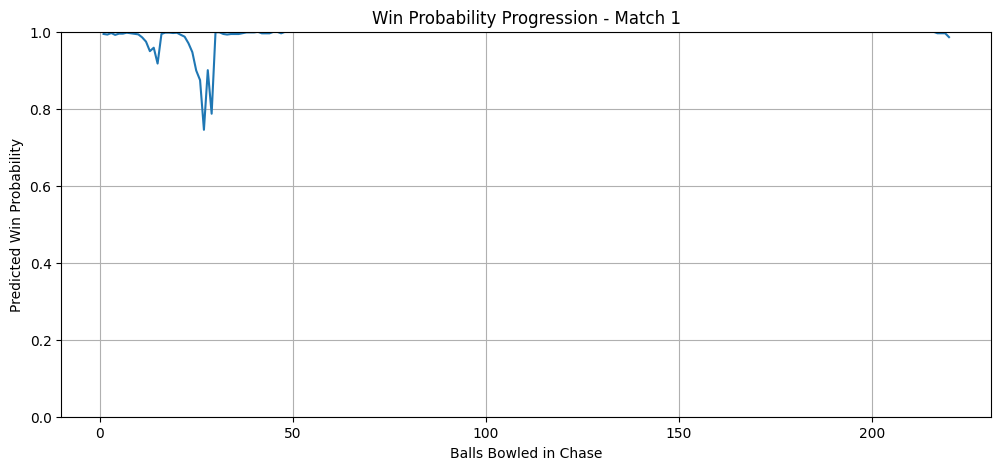

In [ ]:
sample_match_id = wp_df["match_id"].iloc[0]

one_match = wp_df[wp_df["match_id"] == sample_match_id].copy()
one_match = one_match.sort_values("balls_bowled_2nd")

one_match_features = one_match[wp_features].copy()
one_match["predicted_win_probability"] = wp_best_model.predict_proba(one_match_features)[:, 1]

plt.figure(figsize=(12,5))
plt.plot(one_match["balls_bowled_2nd"], one_match["predicted_win_probability"])
plt.xlabel("Balls Bowled in Chase")
plt.ylabel("Predicted Win Probability")
plt.title(f"Win Probability Progression - Match {sample_match_id}")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [ ]:
wp_output = X_wp_test.copy()
wp_output["actual_result"] = y_wp_test.values
wp_output["predicted_result"] = wp_best_preds
wp_output["predicted_win_probability"] = wp_best_probs

wp_output.to_csv("win_probability_predictions.csv", index=False)
print("Saved: win_probability_predictions.csv")

Saved: win_probability_predictions.csv


In [ ]:
from google.colab import files
files.download("win_probability_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install joblib

In [ ]:
import joblib
import json
import os

In [ ]:
os.makedirs("saved_artifacts", exist_ok=True)
print("Folder created: saved_artifacts")

Folder created: saved_artifacts


In [ ]:
joblib.dump(best_model, "saved_artifacts/wicket_prediction_model.pkl")
print("Saved wicket_prediction_model.pkl")

Saved wicket_prediction_model.pkl


In [ ]:
joblib.dump(wp_best_model, "saved_artifacts/win_probability_model.pkl")
print("Saved win_probability_model.pkl")

Saved win_probability_model.pkl


In [ ]:
joblib.dump(kmeans, "saved_artifacts/batter_cluster_model.pkl")
joblib.dump(scaler, "saved_artifacts/batter_cluster_scaler.pkl")
print("Saved batter_cluster_model.pkl")
print("Saved batter_cluster_scaler.pkl")

Saved batter_cluster_model.pkl
Saved batter_cluster_scaler.pkl


In [ ]:
player_stats.to_csv("saved_artifacts/player_stats.csv", index=False)
print("Saved player_stats.csv")

Saved player_stats.csv


In [ ]:
artifacts_info = {
    "wicket_prediction_features": available_features,
    "win_probability_features": wp_features,
    "cluster_features": cluster_features
}

with open("saved_artifacts/features_info.json", "w") as f:
    json.dump(artifacts_info, f, indent=4)

print("Saved features_info.json")

Saved features_info.json


In [ ]:
model_info = {
    "wicket_model_name": str(best_model_name),
    "win_probability_model_name": str(wp_best_model_name),
    "cluster_model": "KMeans"
}

with open("saved_artifacts/model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Saved model_info.json")

Saved model_info.json


In [ ]:
import shutil

shutil.make_archive("icc_cricket_ui_artifacts", "zip", "saved_artifacts")
print("Created: icc_cricket_ui_artifacts.zip")

Created: icc_cricket_ui_artifacts.zip


In [ ]:
from google.colab import files
files.download("icc_cricket_ui_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>